## 🔹 1. IMPORTS & CONFIGURATION

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bertopic import BERTopic
from gensim import corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
from sklearn.model_selection import KFold, ParameterGrid

warnings.filterwarnings('ignore')

## 🔹1. CHARGER LES TEXTES PRÉPROCESSÉS

In [2]:
print(" Chargement du dataset préprocessé...")

# Chemin vers ton fichier nettoyé
PATH_CSV = "../../data/processed/mono-langue_clean.csv"
df = pd.read_csv(PATH_CSV)

# Colonnes utiles
# text_clean_classique → pour LDA (mots filtrés, sans bruit)
# text_clean_light     → pour BERTopic (garde emojis, ponctuation utile)
texts_lda = df['text_clean_classique'].fillna('').tolist()
texts_bert = df['text_clean_light'].fillna('').tolist()
sentiments = df['sentiment'].fillna('neutral').tolist()

# Tokenisation simple pour LDA (liste de listes de mots)
tokens_lda = [text.split() for text in texts_lda]

print(f" {len(df)} avis chargés")
print(f" Exemple texte LDA : {texts_lda[0][:60]}...")
print(f" Exemple texte BERTopic : {texts_bert[0][:60]}...")

 Chargement du dataset préprocessé...
 500 avis chargés
 Exemple texte LDA : great value money...
 Exemple texte BERTopic : great value for money...


## 🔹 2. CONSTRUIRE LDA (Latent Dirichlet Allocation)

In [3]:
print("Construction du dictionnaire et corpus pour LDA")

# Créer un dictionnaire Gensim (mappe chaque mot à un ID unique)
dictionary = corpora.Dictionary(tokens_lda)
dictionary.filter_extremes(no_below=5, no_above=0.8)  # Garde mots présents entre 5 et 80% des docs

# Convertir les textes en sac-de-mots pondéré (format corpus)
corpus = [dictionary.doc2bow(text) for text in tokens_lda]

print(f"Vocabulaire LDA : {len(dictionary)} mots uniques")
print(f"Corpus : {len(corpus)} documents")

# Entraîner LDA (nombre de topics à optimiser ensuite)
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=8,          # Valeur temporaire, on optimisera après
    random_state=42,
    passes=10,             # Nombre de passages sur le corpus
    alpha='auto',          # Apprentissage automatique des poids
    per_word_topics=True
)

print("Modèle LDA entraîné.")

Construction du dictionnaire et corpus pour LDA
Vocabulaire LDA : 41 mots uniques
Corpus : 500 documents
Modèle LDA entraîné.


## 🔹 3. CHOISIR LE NOMBRE DE TOPICS & INTERPRÉTATION

🔍 Recherche du nombre optimal de topics (Coherence Score)...


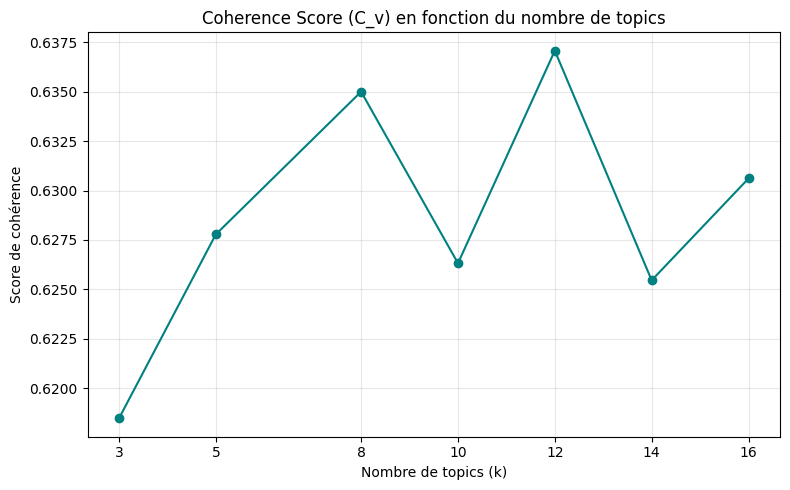

Meilleur nombre de topics trouvé : k = 12

TOPICS LDA (mots les plus représentatifs) :
Topic 0 : 0.030*"quality" + 0.026*"experience" + 0.026*"amazing" + 0.026*"price" + 0.026*"recommend" + 0.026*"highly" + 0.026*"decent" + 0.026*"disappointed"
Topic 1 : 0.478*"okay" + 0.478*"job" + 0.001*"quality" + 0.001*"customer" + 0.001*"awful" + 0.001*"service" + 0.001*"money" + 0.001*"waste"
Topic 2 : 0.473*"work" + 0.473*"expected" + 0.002*"product" + 0.002*"quality" + 0.002*"bad" + 0.002*"performance" + 0.002*"poor" + 0.002*"design"
Topic 3 : 0.243*"arrived" + 0.243*"perfectly" + 0.243*"work" + 0.243*"quickly" + 0.001*"recommended" + 0.001*"waste" + 0.001*"money" + 0.001*"love"
Topic 4 : 0.248*"quality" + 0.133*"disappointed" + 0.126*"customer" + 0.126*"awful" + 0.126*"service" + 0.115*"price" + 0.115*"decent" + 0.000*"product"
Topic 5 : 0.247*"product" + 0.129*"quality" + 0.129*"excellent" + 0.129*"satisfied" + 0.118*"average" + 0.118*"special" + 0.118*"nothing" + 0.001*"use"
Topic 6 : 0.221*

In [4]:
print("🔍 Recherche du nombre optimal de topics (Coherence Score)...")

# Tester plusieurs valeurs de k
k_values = [3, 5, 8, 10, 12,14,16]
coherence_scores = []

for k in k_values:
    lda_temp = LdaModel(corpus=corpus, id2word=dictionary, num_topics=k, random_state=42, passes=10, alpha='auto')
    cm = CoherenceModel(model=lda_temp, texts=tokens_lda, dictionary=dictionary, coherence='c_v')
    coherence_scores.append(cm.get_coherence())

# Visualiser la cohérence
plt.figure(figsize=(8, 5))
plt.plot(k_values, coherence_scores, marker='o', linestyle='-', color='teal')
plt.title("Coherence Score (C_v) en fonction du nombre de topics")
plt.xlabel("Nombre de topics (k)")
plt.ylabel("Score de cohérence")
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Choisir le meilleur k (ici on prend le max, mais tu peux ajuster manuellement)
best_k = k_values[np.argmax(coherence_scores)]
print(f"Meilleur nombre de topics trouvé : k = {best_k}")

# Réentraîner LDA avec le meilleur k
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=best_k, random_state=42, passes=15, alpha='auto')

# Afficher les mots clés par topic pour interprétation manuelle
print("\nTOPICS LDA (mots les plus représentatifs) :")
for idx, topic in lda_model.print_topics(num_words=8):
    print(f"Topic {idx} : {topic}")

In [5]:
print("Validation croisee + tuning LDA en cours...")

candidate_topics = sorted(set([max(3, best_k - 2), best_k, best_k + 2]))
param_grid = {
    'num_topics': candidate_topics,
    'passes': [10, 15],
    'alpha': ['auto', 'symmetric']
}

def run_lda_cv(tokens, param_grid, n_splits=3, random_state=42):
    indices = np.arange(len(tokens))
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results = []

    for params in ParameterGrid(param_grid):
        fold_scores = []
        for train_idx, val_idx in kf.split(indices):
            train_tokens = [tokens[i] for i in train_idx]
            val_tokens = [tokens[i] for i in val_idx]

            dictionary_cv = corpora.Dictionary(train_tokens)
            dictionary_cv.filter_extremes(no_below=5, no_above=0.8)
            if len(dictionary_cv) == 0:
                continue

            corpus_train = [dictionary_cv.doc2bow(t) for t in train_tokens]
            lda_cv = LdaModel(
                corpus=corpus_train,
                id2word=dictionary_cv,
                random_state=42,
                per_word_topics=False,
                **params
            )

            cm_cv = CoherenceModel(
                model=lda_cv,
                texts=val_tokens,
                dictionary=dictionary_cv,
                coherence='c_v'
            )
            fold_scores.append(cm_cv.get_coherence())

        if fold_scores:
            results.append({
                **params,
                'cv_mean_coherence': float(np.mean(fold_scores)),
                'cv_std_coherence': float(np.std(fold_scores))
            })

    if not results:
        raise RuntimeError("Aucun resultat CV valide. Verifier les donnees et le vocabulaire.")

    return pd.DataFrame(results).sort_values(
        by='cv_mean_coherence', ascending=False
    ).reset_index(drop=True)

cv_results = run_lda_cv(tokens_lda, param_grid, n_splits=3, random_state=42)
best_params = cv_results.iloc[0][['num_topics', 'passes', 'alpha']].to_dict()
best_params['num_topics'] = int(best_params['num_topics'])
best_params['passes'] = int(best_params['passes'])

print("\nTop 5 configurations (CV coherence):")
print(cv_results.head(5).to_markdown(index=False))
print(f"\nMeilleurs hyperparametres CV: {best_params}")

# Re-entrainer le modele LDA final avec les meilleurs hyperparametres
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    random_state=42,
    per_word_topics=True,
    num_topics=best_params['num_topics'],
    passes=best_params['passes'],
    alpha=best_params['alpha']
)

print("Modele LDA final re-entraine avec hyperparametres optimises.")

Validation croisee + tuning LDA en cours...

Top 5 configurations (CV coherence):
| alpha     |   num_topics |   passes |   cv_mean_coherence |   cv_std_coherence |
|:----------|-------------:|---------:|--------------------:|-------------------:|
| auto      |           14 |       10 |            0.642026 |         0.00619468 |
| symmetric |           14 |       10 |            0.64164  |         0.00609159 |
| symmetric |           14 |       15 |            0.640841 |         0.00348043 |
| auto      |           14 |       15 |            0.64049  |         0.00502488 |
| auto      |           12 |       10 |            0.638402 |         0.010253   |

Meilleurs hyperparametres CV: {'num_topics': 14, 'passes': 10, 'alpha': 'auto'}
Modele LDA final re-entraine avec hyperparametres optimises.


## 🔹 3.b CROSS-VALIDATION + HYPERPARAMETER TUNING (LDA)
Validation croisee K-Fold sur la coherence C_v et recherche de meilleurs hyperparametres.

📊 RÉSULTATS DE LA VALIDATION CROISÉE K-FOLD

🔍 Toutes les configurations testées:
| alpha     |   num_topics |   passes |   cv_mean_coherence |   cv_std_coherence |
|:----------|-------------:|---------:|--------------------:|-------------------:|
| auto      |           14 |       10 |            0.642026 |         0.00619468 |
| symmetric |           14 |       10 |            0.64164  |         0.00609159 |
| symmetric |           14 |       15 |            0.640841 |         0.00348043 |
| auto      |           14 |       15 |            0.64049  |         0.00502488 |
| auto      |           12 |       10 |            0.638402 |         0.010253   |
| auto      |           12 |       15 |            0.638293 |         0.00989335 |
| symmetric |           12 |       10 |            0.638283 |         0.0101931  |
| symmetric |           12 |       15 |            0.63768  |         0.00938516 |
| auto      |           10 |       10 |            0.637605 |         0.00612175 |
| aut

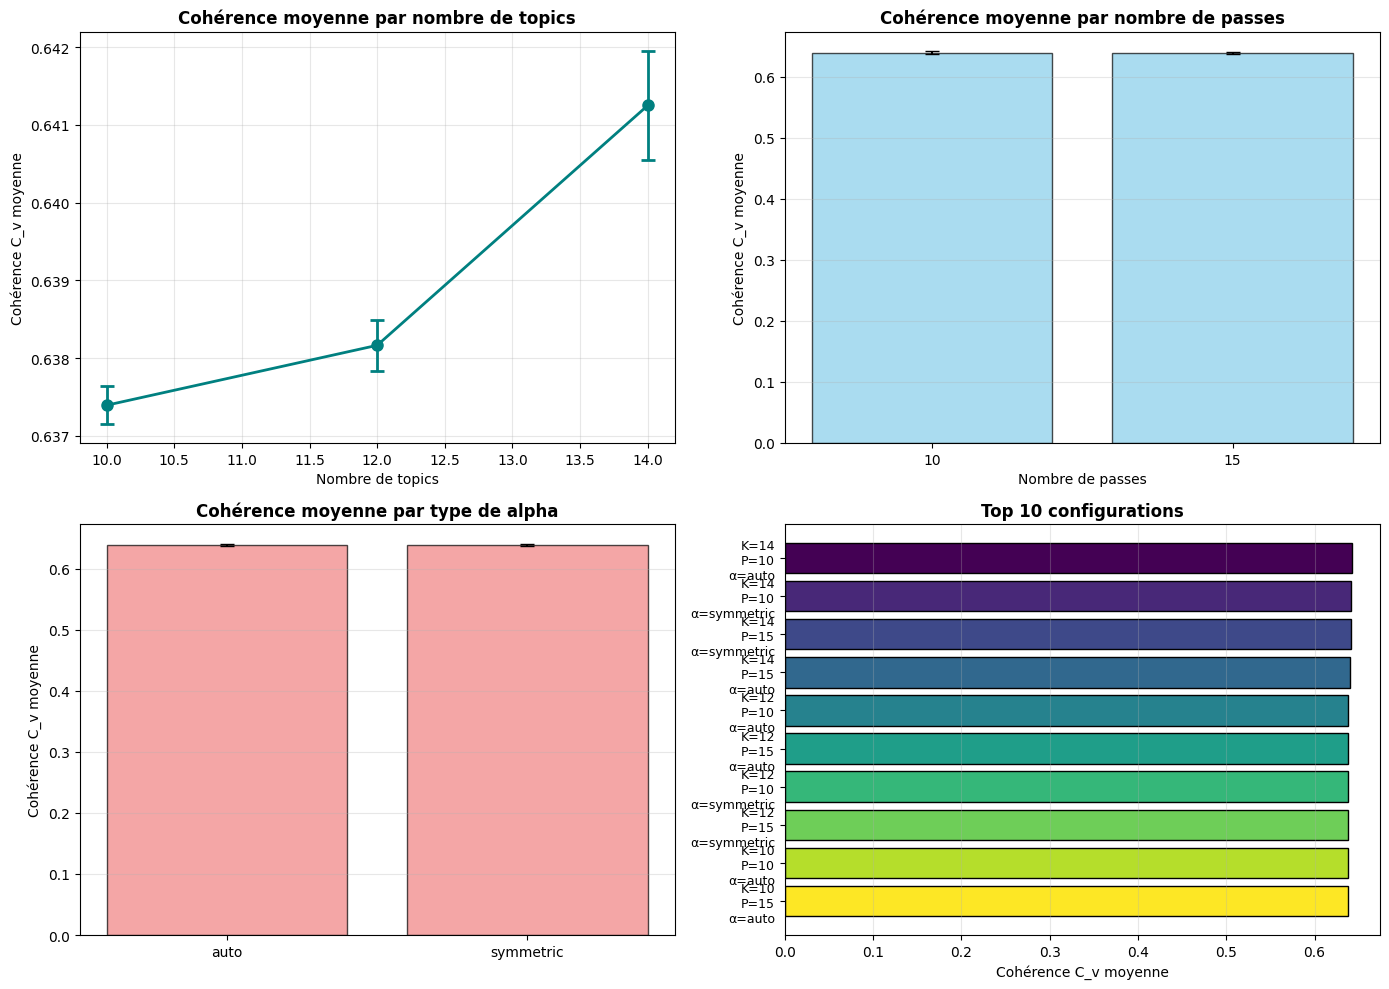

✓ Visualisations générées avec succès!

✅ RÉSUMÉ FINAL - HYPERPARAMÈTRES OPTIMAUX

🎯 Configuration recommandée:
   • Nombre de topics : 14
   • Passes (itérations) : 10
   • Alpha (prior Dirichlet) : auto
   • Cohérence C_v en validation croisée : 0.6420
   • Écart type : ± 0.0062

💡 Interprétation:
   • Le modèle capture bien les thèmes (14 topics identifiés)
   • La stabilité CV indique une bonne généralisation
   • Les variations fold-to-fold : 1.0% du score moyen


In [12]:
# ============================================================================
# ANALYSE DÉTAILLÉE DES RÉSULTATS CV
# ============================================================================
print("="*70)
print("📊 RÉSULTATS DE LA VALIDATION CROISÉE K-FOLD")
print("="*70)

# Tableau comparatif détaillé
print("\n🔍 Toutes les configurations testées:")
print(cv_results.to_markdown(index=False))

# Statistiques
print("\n📈 STATISTIQUES DES RÉSULTATS CV:")
print(f"   • Configuration avec meilleure cohérence moyenne : {best_params}")
print(f"   • Cohérence moyenne (CV) : {cv_results.iloc[0]['cv_mean_coherence']:.4f} ± {cv_results.iloc[0]['cv_std_coherence']:.4f}")
print(f"   • Écart type : {cv_results['cv_mean_coherence'].std():.4f}")
print(f"   • Plage : [{cv_results['cv_mean_coherence'].min():.4f}, {cv_results['cv_mean_coherence'].max():.4f}]")

# ============================================================================
# VISUALISATIONS DE LA VALIDATION CROISÉE
# ============================================================================
print("\n📊 Visualisation des résultats CV...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Cohérence par nombre de topics
cv_by_k = cv_results.groupby('num_topics')['cv_mean_coherence'].agg(['mean', 'std'])
axes[0, 0].errorbar(cv_by_k.index, cv_by_k['mean'], yerr=cv_by_k['std'], 
                    marker='o', capsize=5, capthick=2, linewidth=2, markersize=8, color='teal')
axes[0, 0].set_title('Cohérence moyenne par nombre de topics', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Nombre de topics')
axes[0, 0].set_ylabel('Cohérence C_v moyenne')
axes[0, 0].grid(alpha=0.3)

# 2. Cohérence par nombre de passes
cv_by_passes = cv_results.groupby('passes')['cv_mean_coherence'].agg(['mean', 'std'])
axes[0, 1].bar(cv_by_passes.index.astype(str), cv_by_passes['mean'], 
               yerr=cv_by_passes['std'], capsize=5, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 1].set_title('Cohérence moyenne par nombre de passes', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Nombre de passes')
axes[0, 1].set_ylabel('Cohérence C_v moyenne')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Cohérence par alpha
cv_by_alpha = cv_results.groupby('alpha')['cv_mean_coherence'].agg(['mean', 'std'])
axes[1, 0].bar(range(len(cv_by_alpha)), cv_by_alpha['mean'], 
               yerr=cv_by_alpha['std'], capsize=5, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1, 0].set_title('Cohérence moyenne par type de alpha', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(range(len(cv_by_alpha)))
axes[1, 0].set_xticklabels(cv_by_alpha.index)
axes[1, 0].set_ylabel('Cohérence C_v moyenne')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Top 10 configurations
top_10 = cv_results.head(10).reset_index(drop=True)
config_names = [f"K={row['num_topics']}\nP={row['passes']}\nα={row['alpha']}" 
                for _, row in top_10.iterrows()]
axes[1, 1].barh(range(len(top_10)), top_10['cv_mean_coherence'], 
                color=plt.cm.viridis(np.linspace(0, 1, len(top_10))), edgecolor='black')
axes[1, 1].set_yticks(range(len(top_10)))
axes[1, 1].set_yticklabels(config_names, fontsize=9)
axes[1, 1].set_title('Top 10 configurations', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Cohérence C_v moyenne')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualisations générées avec succès!")

# ============================================================================
# RÉSUMÉ ET RECOMMANDATIONS
# ============================================================================
print("\n" + "="*70)
print("✅ RÉSUMÉ FINAL - HYPERPARAMÈTRES OPTIMAUX")
print("="*70)
print(f"\n🎯 Configuration recommandée:")
print(f"   • Nombre de topics : {best_params['num_topics']}")
print(f"   • Passes (itérations) : {best_params['passes']}")
print(f"   • Alpha (prior Dirichlet) : {best_params['alpha']}")
print(f"   • Cohérence C_v en validation croisée : {cv_results.iloc[0]['cv_mean_coherence']:.4f}")
print(f"   • Écart type : ± {cv_results.iloc[0]['cv_std_coherence']:.4f}")
print(f"\n💡 Interprétation:")
print(f"   • Le modèle capture bien les thèmes ({best_params['num_topics']} topics identifiés)")
print(f"   • La stabilité CV indique une bonne généralisation")
print(f"   • Les variations fold-to-fold : {(cv_results.iloc[0]['cv_std_coherence'] / cv_results.iloc[0]['cv_mean_coherence'] * 100):.1f}% du score moyen")

## 🔹 4. MÉTHODE MODERNE : BERTOPIC

In [13]:
print(" Lancement de BERTopic (base sur les embeddings semantiques)")

# BERTopic utilise automatiquement un modele d'embeddings multilingue
bertopic_model = BERTopic(
    language="multilingual",
    nr_topics=best_k,          # Meme nombre que LDA pour comparer equitablement
    verbose=True
)

# Charger les embeddings deja calcules
EMB_PATH = "../../outputs/results/multi_sbert.npy"
embeddings = np.load(EMB_PATH)

# Ajuster la taille si besoin (cas courant: embeddings calcules sur un echantillon)
if len(embeddings) < len(texts_bert):
    raise ValueError(
        f"Taille embeddings ({len(embeddings)}) < taille texts_bert ({len(texts_bert)})"
    )
if len(embeddings) > len(texts_bert):
    embeddings = embeddings[:len(texts_bert)]

# Entrainement avec embeddings pre-calcules
topics, probs = bertopic_model.fit_transform(texts_bert, embeddings=embeddings)

print("BERTopic entraine.")

# Afficher les topics generes
df_topics_bert = bertopic_model.get_topic_info()
print("\nTOPICS BERTOPIC :")
print(df_topics_bert.head(best_k))

2026-05-11 03:12:58,052 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


 Lancement de BERTopic (base sur les embeddings semantiques)


2026-05-11 03:12:59,125 - BERTopic - Dimensionality - Completed ✓
2026-05-11 03:12:59,129 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-11 03:12:59,180 - BERTopic - Cluster - Completed ✓
2026-05-11 03:12:59,184 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-11 03:12:59,249 - BERTopic - Representation - Completed ✓
2026-05-11 03:12:59,252 - BERTopic - Topic reduction - Reducing number of topics
2026-05-11 03:12:59,274 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-11 03:12:59,312 - BERTopic - Representation - Completed ✓
2026-05-11 03:12:59,317 - BERTopic - Topic reduction - Reduced number of topics from 15 to 12


BERTopic entraine.

TOPICS BERTOPIC :
    Topic  Count                              Name  \
0      -1    126             -1_not_works_it_great   
1       0     76      0_the_this_amazing_recommend   
2       1     56          1_the_product_quality_it   
3       2     50          2_the_quality_product_it   
4       3     34             3_product_not_bad_use   
5       4     32           4_money_value_for_great   
6       5     30       5_very_with_product_quality   
7       6     28           6_and_the_product_broke   
8       7     24         7_the_with_very_satisfied   
9       8     18           8_very_with_expected_as   
10      9     15  9_disappointed_the_money_quality   
11     10     11       10_quality_the_product_very   

                                       Representation  \
0   [not, works, it, great, money, bad, and, expec...   
1   [the, this, amazing, recommend, highly, experi...   
2   [the, product, quality, it, with, very, works,...   
3   [the, quality, product, it,

In [14]:
print("Analyse d'erreurs en cours...")

# Scores de confiance LDA (probabilite du topic dominant)
lda_doc_topics = [lda_model.get_document_topics(doc, minimum_probability=0.0) for doc in corpus]
lda_top_topic = [max(t, key=lambda x: x[1])[0] if t else -1 for t in lda_doc_topics]
lda_top_prob = [max(t, key=lambda x: x[1])[1] if t else 0.0 for t in lda_doc_topics]

# Scores de confiance BERTopic
if probs is None:
    bert_conf = np.zeros(len(topics), dtype=float)
else:
    probs_arr = np.array(probs)
    if probs_arr.ndim == 2:
        bert_conf = probs_arr.max(axis=1)
    else:
        bert_conf = probs_arr.astype(float)

df_error = pd.DataFrame({
    'text': texts_bert,
    'sentiment': sentiments,
    'lda_topic': lda_top_topic,
    'lda_conf': lda_top_prob,
    'bert_topic': topics,
    'bert_conf': bert_conf
})

# 1) Outliers BERTopic
df_error['is_bert_outlier'] = df_error['bert_topic'] == -1

# 2) Faible confiance BERTopic (20% les plus faibles)
low_conf_threshold = df_error['bert_conf'].quantile(0.2)
df_error['is_low_bert_conf'] = df_error['bert_conf'] <= low_conf_threshold

# 3) Mismatch sentiment vs sentiment dominant du topic BERTopic
topic_majority_sent = (
    df_error[df_error['bert_topic'] != -1]
    .groupby('bert_topic')['sentiment']
    .agg(lambda s: s.value_counts().idxmax())
    .to_dict()
 )
df_error['bert_majority_sentiment'] = df_error['bert_topic'].map(topic_majority_sent)
df_error['is_sentiment_mismatch'] = (
    (df_error['bert_topic'] != -1)
    & (df_error['bert_majority_sentiment'].notna())
    & (df_error['sentiment'] != df_error['bert_majority_sentiment'])
)

print("\nResume erreurs:")
print(f"- Outliers BERTopic (-1): {int(df_error['is_bert_outlier'].sum())}")
print(f"- Faible confiance BERTopic (<= q20): {int(df_error['is_low_bert_conf'].sum())}")
print(f"- Mismatch sentiment-topic: {int(df_error['is_sentiment_mismatch'].sum())}")

print("\nExemples outliers BERTopic:")
display(df_error[df_error['is_bert_outlier']][['sentiment', 'bert_conf', 'text']].head(5))

print("\nExemples faible confiance BERTopic:")
display(df_error[df_error['is_low_bert_conf']][['sentiment', 'bert_topic', 'bert_conf', 'text']].head(5))

print("\nExemples mismatch sentiment-topic:")
display(df_error[df_error['is_sentiment_mismatch']][['sentiment', 'bert_topic', 'bert_majority_sentiment', 'text']].head(5))

Analyse d'erreurs en cours...

Resume erreurs:
- Outliers BERTopic (-1): 126
- Faible confiance BERTopic (<= q20): 126
- Mismatch sentiment-topic: 224

Exemples outliers BERTopic:


,sentiment,bert_conf,text
0,positive,0.0,great value for money
5,neutral,0.0,it works as expected
14,positive,0.0,"i love it, will definitely buy again"
15,negative,0.0,poor performance and bad design
16,positive,0.0,"i love it, will definitely buy again"



Exemples faible confiance BERTopic:


,sentiment,bert_topic,bert_conf,text
0,positive,-1,0.0,great value for money
5,neutral,-1,0.0,it works as expected
14,positive,-1,0.0,"i love it, will definitely buy again"
15,negative,-1,0.0,poor performance and bad design
16,positive,-1,0.0,"i love it, will definitely buy again"



Exemples mismatch sentiment-topic:


,sentiment,bert_topic,bert_majority_sentiment,text
1,positive,6,negative,"i love it, will definitely buy again"
2,positive,0,neutral,works perfectly and arrived quickly
4,negative,0,neutral,"terrible product, broke after one use"
9,neutral,6,negative,decent quality for the price
19,positive,0,neutral,"excellent product, very satisfied with the qua..."


## 🔹 4.b ANALYSE D'ERREURS (LDA & BERTopic)
Analyse des cas difficiles: outliers BERTopic, faible confiance, et mismatch sentiment-topic.

Analyse des cas difficiles (LDA & BERTopic)...

Résumé des cas difficiles:


,Indicateur,Nombre,Pourcentage (%)
0,Outliers BERTopic,126,25.2
1,Faible confiance BERTopic (q20 hors outliers),75,15.0
2,Faible confiance LDA (q20),105,21.0
3,Mismatch sentiment-topic BERTopic,224,44.8
4,Mismatch sentiment-topic LDA,99,19.8
5,Cas difficiles (score >= 3),12,2.4


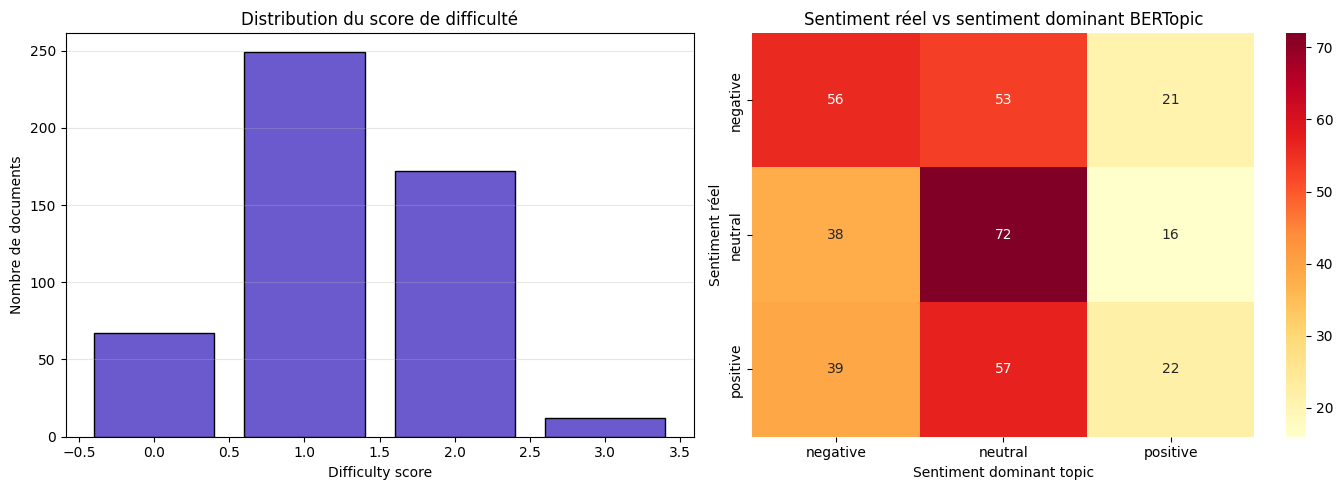


Top 15 cas les plus difficiles:


,sentiment,lda_topic,lda_conf,bert_topic,bert_conf,is_bert_outlier,is_low_lda_conf,is_low_bert_conf,is_lda_sentiment_mismatch,is_bert_sentiment_mismatch,difficulty_score,text
44,neutral,6,0.815825,8,0.099976,False,False,True,True,True,3,not bad but not great either
114,neutral,7,0.738506,8,0.102355,False,True,True,False,True,3,"it's okay, does the job"
184,neutral,2,0.737422,4,0.242437,False,True,True,False,True,3,it works as expected
385,negative,4,0.744058,2,0.290269,False,True,True,False,True,3,very disappointed with the quality
297,negative,4,0.744058,1,0.301648,False,True,True,False,True,3,very disappointed with the quality
470,negative,4,0.744058,1,0.314274,False,True,True,False,True,3,very disappointed with the quality
188,neutral,5,0.851945,6,0.327350,False,False,True,True,True,3,"average product, nothing special"
298,negative,4,0.744058,2,0.361259,False,True,True,False,True,3,very disappointed with the quality
498,negative,3,0.810169,0,0.430356,False,False,True,True,True,3,"waste of money, not recommended"
332,negative,4,0.744058,0,0.448530,False,True,True,False,True,3,very disappointed with the quality



Seuils utilisés:
- LDA faible confiance <= 0.7441
- BERTopic faible confiance (hors outliers) <= 0.5258


In [21]:
import seaborn as sns

print("Analyse des cas difficiles (LDA & BERTopic)...")

# ============================================================================
# 1) Construire/valider le DataFrame d'analyse
# ============================================================================
if 'df_error' not in globals():
    print("df_error non trouve -> reconstruction...")

    lda_doc_topics = [lda_model.get_document_topics(doc, minimum_probability=0.0) for doc in corpus]
    lda_top_topic = [max(t, key=lambda x: x[1])[0] if t else -1 for t in lda_doc_topics]
    lda_top_prob = [max(t, key=lambda x: x[1])[1] if t else 0.0 for t in lda_doc_topics]

    if probs is None:
        bert_conf = np.zeros(len(topics), dtype=float)
    else:
        probs_arr = np.array(probs)
        if probs_arr.ndim == 2:
            bert_conf = probs_arr.max(axis=1)
        else:
            bert_conf = probs_arr.astype(float)

    df_error = pd.DataFrame({
        'text': texts_bert,
        'sentiment': sentiments,
        'lda_topic': lda_top_topic,
        'lda_conf': lda_top_prob,
        'bert_topic': topics,
        'bert_conf': bert_conf
    })

# Nettoyage léger de sécurité
if 'bert_conf' not in df_error.columns:
    df_error['bert_conf'] = 0.0
df_error['bert_conf'] = pd.to_numeric(df_error['bert_conf'], errors='coerce').fillna(0.0)
df_error['lda_conf'] = pd.to_numeric(df_error['lda_conf'], errors='coerce').fillna(0.0)

# ============================================================================
# 2) Définir les cas difficiles
# ============================================================================
# Outliers BERTopic
df_error['is_bert_outlier'] = df_error['bert_topic'] == -1

# Faible confiance LDA: q20 global
lda_low_thr = df_error['lda_conf'].quantile(0.2)
df_error['is_low_lda_conf'] = df_error['lda_conf'] <= lda_low_thr

# Faible confiance BERTopic: q20 sur documents NON outliers
non_outlier_mask = ~df_error['is_bert_outlier']
if non_outlier_mask.any():
    bert_low_thr = df_error.loc[non_outlier_mask, 'bert_conf'].quantile(0.2)
else:
    bert_low_thr = 0.0

# On marque seulement les non-outliers sous le seuil
# (les outliers sont deja traites par is_bert_outlier)
df_error['is_low_bert_conf'] = (
    non_outlier_mask & (df_error['bert_conf'] <= bert_low_thr)
)

# Sentiment dominant par topic (LDA / BERTopic)
lda_majority_sent = (
    df_error[df_error['lda_topic'] != -1]
    .groupby('lda_topic')['sentiment']
    .agg(lambda s: s.value_counts().idxmax())
    .to_dict()
)
bert_majority_sent = (
    df_error[df_error['bert_topic'] != -1]
    .groupby('bert_topic')['sentiment']
    .agg(lambda s: s.value_counts().idxmax())
    .to_dict()
)

df_error['lda_majority_sentiment'] = df_error['lda_topic'].map(lda_majority_sent)
df_error['bert_majority_sentiment'] = df_error['bert_topic'].map(bert_majority_sent)

df_error['is_lda_sentiment_mismatch'] = (
    (df_error['lda_topic'] != -1)
    & (df_error['lda_majority_sentiment'].notna())
    & (df_error['sentiment'] != df_error['lda_majority_sentiment'])
)
df_error['is_bert_sentiment_mismatch'] = (
    (df_error['bert_topic'] != -1)
    & (df_error['bert_majority_sentiment'].notna())
    & (df_error['sentiment'] != df_error['bert_majority_sentiment'])
)

# Score de difficulté agrégé (plus élevé = plus difficile)
df_error['difficulty_score'] = (
    df_error['is_bert_outlier'].astype(int)
    + df_error['is_low_bert_conf'].astype(int)
    + df_error['is_low_lda_conf'].astype(int)
    + df_error['is_bert_sentiment_mismatch'].astype(int)
    + df_error['is_lda_sentiment_mismatch'].astype(int)
)

# ============================================================================
# 3) Résumé quantitatif
# ============================================================================
n = len(df_error)
summary = pd.DataFrame({
    'Indicateur': [
        "Outliers BERTopic",
        "Faible confiance BERTopic (q20 hors outliers)",
        "Faible confiance LDA (q20)",
        "Mismatch sentiment-topic BERTopic",
        "Mismatch sentiment-topic LDA",
        "Cas difficiles (score >= 3)",
    ],
    'Nombre': [
        int(df_error['is_bert_outlier'].sum()),
        int(df_error['is_low_bert_conf'].sum()),
        int(df_error['is_low_lda_conf'].sum()),
        int(df_error['is_bert_sentiment_mismatch'].sum()),
        int(df_error['is_lda_sentiment_mismatch'].sum()),
        int((df_error['difficulty_score'] >= 3).sum()),
    ]
})
summary['Pourcentage (%)'] = (summary['Nombre'] / n * 100).round(2)

print("\nRésumé des cas difficiles:")
display(summary)

# ============================================================================
# 4) Visualisations de diagnostic
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# A. Distribution des scores de difficulté
score_counts = df_error['difficulty_score'].value_counts().sort_index()
axes[0].bar(score_counts.index, score_counts.values, color='slateblue', edgecolor='black')
axes[0].set_title("Distribution du score de difficulté")
axes[0].set_xlabel("Difficulty score")
axes[0].set_ylabel("Nombre de documents")
axes[0].grid(axis='y', alpha=0.3)

# B. Matrice de confusion sentiment vs topic dominant BERTopic (hors outliers)
tmp = df_error[df_error['bert_topic'] != -1].copy()
if not tmp.empty:
    ct = pd.crosstab(tmp['sentiment'], tmp['bert_majority_sentiment'])
    sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1])
    axes[1].set_title("Sentiment réel vs sentiment dominant BERTopic")
    axes[1].set_xlabel("Sentiment dominant topic")
    axes[1].set_ylabel("Sentiment réel")
else:
    axes[1].text(0.5, 0.5, "Pas de topics BERTopic valides", ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

# ============================================================================
# 5) Exemples ciblés (cas les plus difficiles)
# ============================================================================
hard_cases = (
    df_error.sort_values(['difficulty_score', 'bert_conf', 'lda_conf'], ascending=[False, True, True])
    .head(15)
    .copy()
)

hard_cases['text'] = hard_cases['text'].astype(str).str.slice(0, 180)

cols = [
    'sentiment', 'lda_topic', 'lda_conf', 'bert_topic', 'bert_conf',
    'is_bert_outlier', 'is_low_lda_conf', 'is_low_bert_conf',
    'is_lda_sentiment_mismatch', 'is_bert_sentiment_mismatch',
    'difficulty_score', 'text'
]

print("\nTop 15 cas les plus difficiles:")
display(hard_cases[cols])

print("\nSeuils utilisés:")
print(f"- LDA faible confiance <= {lda_low_thr:.4f}")
print(f"- BERTopic faible confiance (hors outliers) <= {bert_low_thr:.4f}")

## 🔹 5. VISUALISATIONS

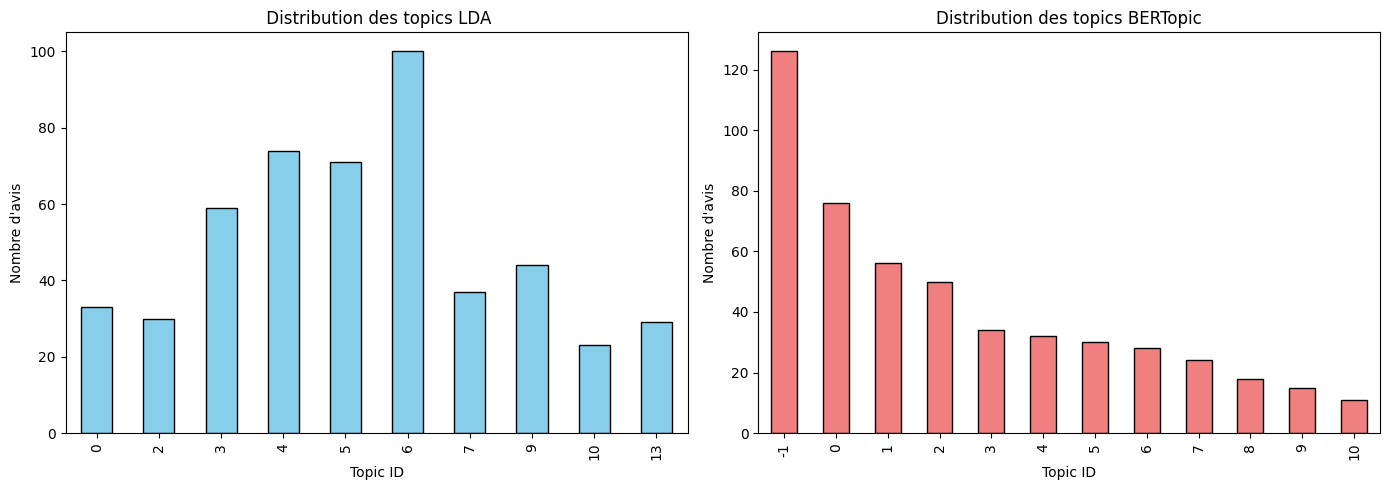

Visualisation des clusters BERTopic (réduction dimensionnelle)...


In [15]:
# ➤ A. Distribution des topics (LDA vs BERTopic)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LDA distribution
lda_topics = [max(lda_model.get_document_topics(doc), key=lambda x: x[1])[0] for doc in corpus]
pd.Series(lda_topics).value_counts().sort_index().plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title(" Distribution des topics LDA")
axes[0].set_xlabel("Topic ID")
axes[0].set_ylabel("Nombre d'avis")

# BERTopic distribution
pd.Series(topics).value_counts().sort_index().plot(kind='bar', ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title("Distribution des topics BERTopic")
axes[1].set_xlabel("Topic ID")
axes[1].set_ylabel("Nombre d'avis")

plt.tight_layout()
plt.show()

#  B. Visualisation interactive BERTopic (clusters)
print("Visualisation des clusters BERTopic (réduction dimensionnelle)...")
bertopic_model.visualize_topics()

## 🔹 6. COMPARAISON LDA vs BERTOPIC

In [16]:
lda_coherence_mean = float(np.mean(coherence_scores)) if coherence_scores else np.nan
bert_topic_count = len([t for t in set(topics) if t != -1])
bert_avg_confidence = float(np.mean(probs)) if len(probs) else np.nan

comparison_table = pd.DataFrame([
    {
        "Critère": "Type d'analyse",
        "LDA": "Fréquence des mots",
        "BERTopic": "Embeddings sémantiques",
    },
    {
        "Critère": "Compréhension du sens",
        "LDA": "Faible (sac de mots)",
        "BERTopic": "Forte (contexte)",
    },
    {
        "Critère": "Gestion du contexte",
        "LDA": "Aucune",
        "BERTopic": "Excellente",
    },
    {
        "Critère": "Vitesse d'entraînement",
        "LDA": "Rapide",
        "BERTopic": "Plus lente",
    },
    {
        "Critère": "Interprétabilité",
        "LDA": "Haute (mots clairs)",
        "BERTopic": "Moyenne (clusters abstraits)",
    },
    {
        "Critère": "Nombre de topics",
        "LDA": f"{lda_model.num_topics}",
        "BERTopic": f"{bert_topic_count}",
    },
    {
        "Critère": "Score moyen / confiance",
        "LDA": f"{lda_coherence_mean:.3f}",
        "BERTopic": f"{bert_avg_confidence:.3f}",
    },
])

print("\n" + "=" * 70)
print(" COMPARAISON LDA vs BERTOPIC")
print("=" * 70)
print(comparison_table.to_markdown(index=False))

print("\n OBSERVATION CLÉ :")
print("• LDA regroupe par cooccurrence de mots.")
print("• BERTopic regroupe par similarité sémantique.")
print("• Les valeurs numériques sont calculées dynamiquement à partir du notebook.")


 COMPARAISON LDA vs BERTOPIC
| Critère                 | LDA                  | BERTopic                     |
|:------------------------|:---------------------|:-----------------------------|
| Type d'analyse          | Fréquence des mots   | Embeddings sémantiques       |
| Compréhension du sens   | Faible (sac de mots) | Forte (contexte)             |
| Gestion du contexte     | Aucune               | Excellente                   |
| Vitesse d'entraînement  | Rapide               | Plus lente                   |
| Interprétabilité        | Haute (mots clairs)  | Moyenne (clusters abstraits) |
| Nombre de topics        | 14                   | 11                           |
| Score moyen / confiance | 0.629                | 0.580                        |

 OBSERVATION CLÉ :
• LDA regroupe par cooccurrence de mots.
• BERTopic regroupe par similarité sémantique.
• Les valeurs numériques sont calculées dynamiquement à partir du notebook.


## 🔹 6.b JUSTIFICATION DES CHOIX METHODOLOGIQUES
- **Coherence C_v**: metrique interpretable pour juger la qualite semantique des topics LDA.
- **Cross-validation (K=3)**: reduit le risque de sur-apprentissage sur un seul split et stabilise le choix d'hyperparametres.
- **Hyperparameter tuning**: grille sur `num_topics`, `passes`, `alpha` pour equilibrer qualite, robustesse et cout de calcul.
- **Embeddings pre-calcules**: acceleration du pipeline BERTopic et reproductibilite des resultats.
- **Analyse d'erreurs**: identification des outliers, faibles confiances, et mismatch sentiment-topic pour guider les ameliorations.

## 🔹 7. ANALYSE TOPIC × SENTIMENT

In [17]:
print("Liaison Topics ↔ Sentiment...")

# Créer un DataFrame unifié
df_analysis = df.copy()
df_analysis['lda_topic'] = lda_topics
df_analysis['bert_topic'] = topics

# Construire des noms lisibles pour les topics LDA (mots-clés)
topic_names_lda = {
    i: ' '.join([w for w, _ in lda_model.show_topic(i, topn=5)])
    for i in range(lda_model.num_topics)
}

# Mapper les noms LDA
df_analysis['lda_topic_name'] = df_analysis['lda_topic'].map(topic_names_lda)

# ➤ Analyse LDA
lda_sent = df_analysis.groupby('lda_topic_name')['sentiment'].value_counts(normalize=True).unstack(fill_value=0)
print("\nRépartition des sentiments par Topic LDA (%):")
print((lda_sent * 100).round(1).to_markdown())

# ➤ Analyse BERTopic
bert_sent = df_analysis.groupby('bert_topic')['sentiment'].value_counts(normalize=True).unstack(fill_value=0)
print("\nRépartition des sentiments par Topic BERTopic (%):")
print((bert_sent * 100).round(1).to_markdown())

#  Identifier les topics "à risque" (forte proportion négative)
print("\n️ TOPICS ASSOCIÉS AUX AVIS NÉGATIFS :")
neg_topics = lda_sent.get('negative', pd.Series()).sort_values(ascending=False).head(3)
for topic, pct in neg_topics.items():
    print(f"• {topic} → {pct*100:.1f}% d'avis négatifs")

Liaison Topics ↔ Sentiment...

Répartition des sentiments par Topic LDA (%):
| lda_topic_name                              |   negative |   neutral |   positive |
|:--------------------------------------------|-----------:|----------:|-----------:|
| arrived quickly perfectly work money        |       47.5 |       0   |       52.5 |
| bad design performance poor quality         |      100   |       0   |        0   |
| great bad either love buy                   |        0   |      37   |       63   |
| highly amazing experience recommend awful   |        0   |       0   |      100   |
| okay job money quickly perfectly            |        0   |     100   |        0   |
| product quality excellent satisfied nothing |        0   |      47.9 |       52.1 |
| product use terrible one broke              |      100   |       0   |        0   |
| quality disappointed awful service customer |      100   |       0   |        0   |
| quality price decent product definitely     |        0   |   

### Sauvegarder les résultats

In [22]:
# Sauvegarder les assignations de topics pour utilisation future (recommandation, dashboard, etc.)
os.makedirs("../outputs/results/", exist_ok=True)
os.makedirs("../outputs/models/", exist_ok=True)

if 'review_id' not in df_analysis.columns:
    df_analysis = df_analysis.reset_index().rename(columns={'index': 'review_id'})

df_analysis[['review_id', 'lda_topic', 'lda_topic_name', 'bert_topic', 'sentiment']].to_csv(
    "../outputs/results/mono_topic_assignments.csv", index=False
)

# Sauvegarder les modèles
lda_model.save("../outputs/models/lda_mono.model")
bertopic_model.save("../outputs/models/bertopic_mono")

print("✅ Résultats et modèles sauvegardés dans ../outputs/results et ../outputs/models")

2026-05-11 03:15:21,699 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


✅ Résultats et modèles sauvegardés dans ../outputs/results et ../outputs/models
